In [21]:
# ==========================================================
# Customer Churn Prediction
# Notebook 2: Exploratory Data Analysis (EDA)
# ==========================================================
#
# Objective:
# Explore the cleaned dataset to understand customer characteristics, identify patterns related to churn, and
# generate insights that will support feature selection and model development.
# ==========================================================

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel(
    "Telco Customer Churn Cleaned.xlsx"
)

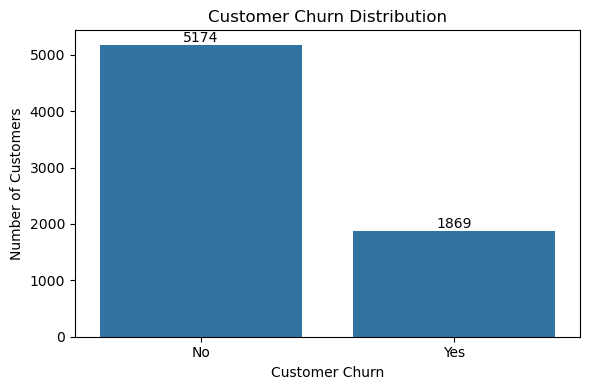

In [6]:
df["Churn"] = df["Churn Value"].map({
    0: "No",
    1: "Yes"
})

# Plot customer churn distribution
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    order=["No", "Yes"]
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [7]:
## Observation

# The dataset is moderately imbalanced. Approximately 73.5% of customers did not churn, while 26.5% churned.

# This imbalance should be considered during model development. Evaluation metrics such as Recall, Precision, and F1-score are more appropriate than relying solely on Accuracy.

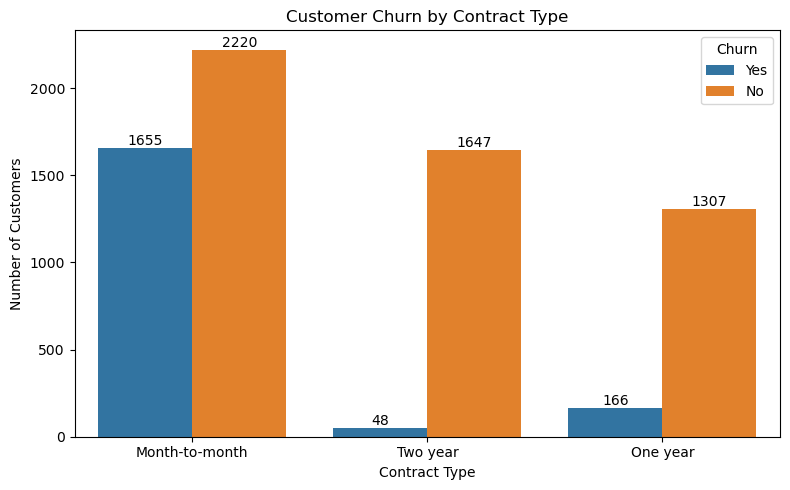

In [8]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [9]:
## Observation
# Customers with month-to-month contracts have the highest churn.
# Customers with one-year and two-year contracts are much less likely to churn.
# This suggests that contract type is an important predictor of customer churn.

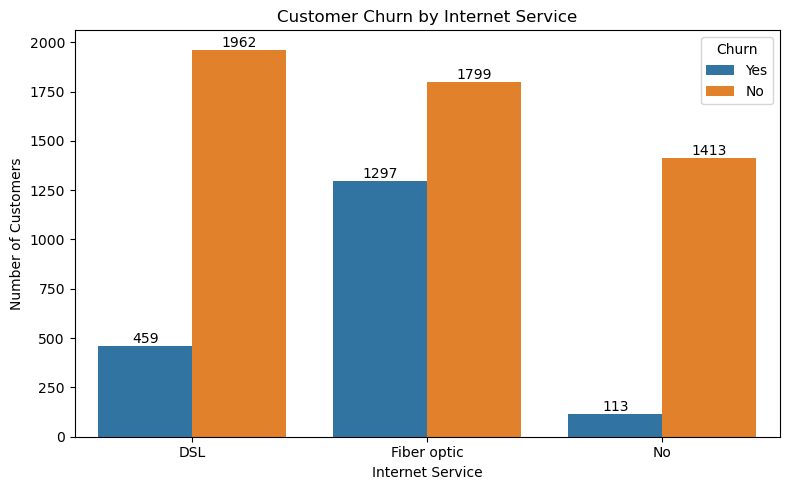

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [11]:
## Observation
# Customers using Fiber Optic internet have the highest number of churn cases.
# Customers without internet service have the lowest churn.
# The type of internet service may influence customer retention.

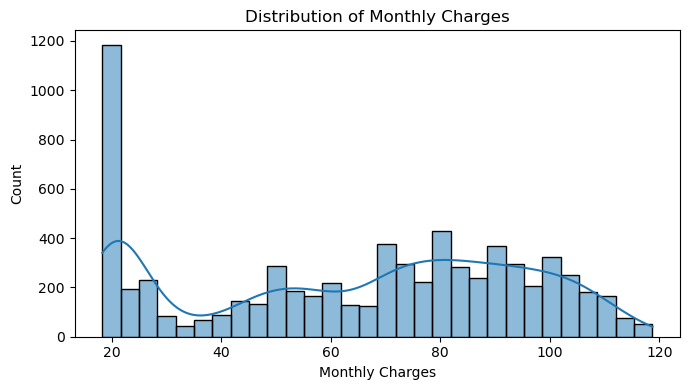

In [12]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [13]:
## Observation
# Monthly charges range from approximately $18 to $120.
# Most customers pay between $70 and $100 per month.
# The distribution is not perfectly normal, indicating multiple pricing plans.

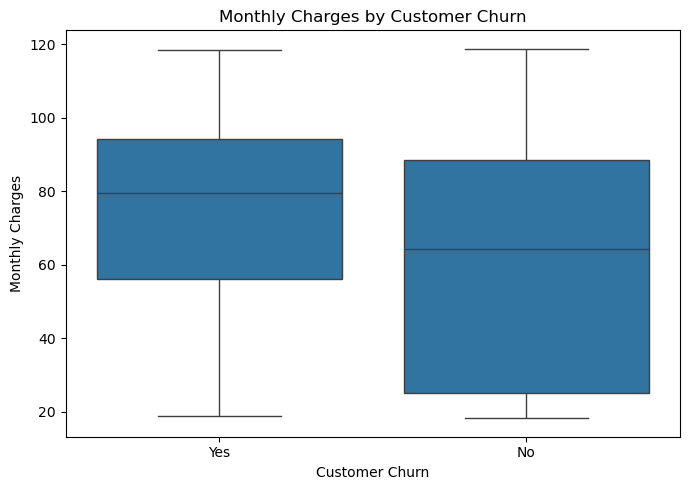

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [15]:
## Observation
# Customers who churn generally have higher monthly charges than those who remain.
# This suggests that higher monthly costs may contribute to customer churn.

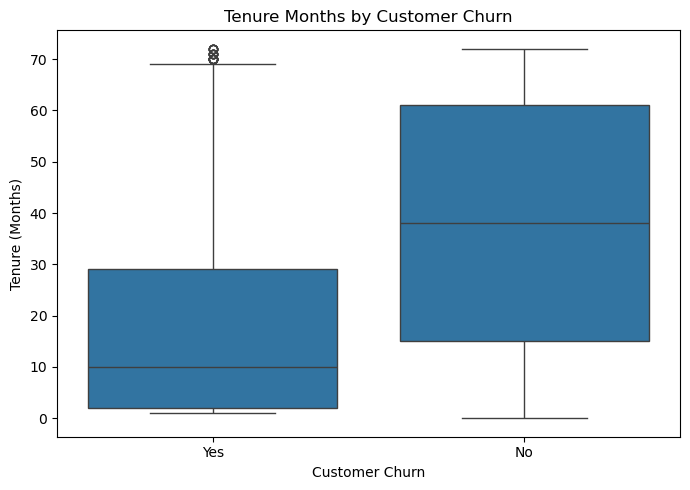

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure Months"
)

plt.title("Tenure Months by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [17]:
## Observation
# Customers who churn generally have shorter tenure than customers who stay.
# Long-term customers are more likely to remain with the company.
# Customer tenure appears to be an important factor in predicting churn.

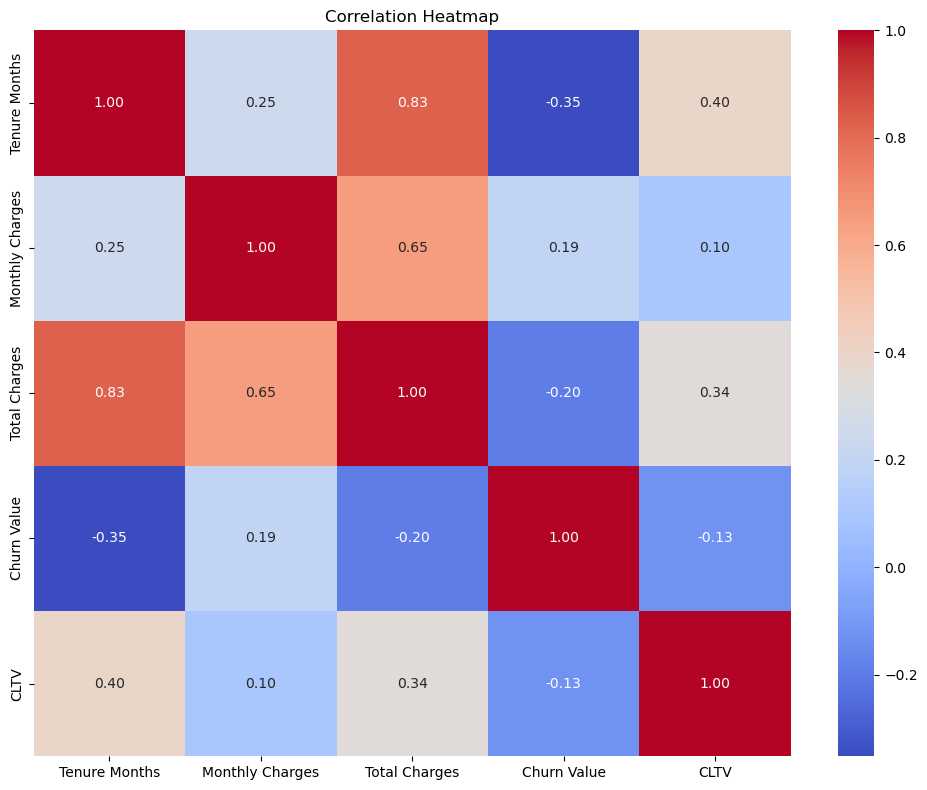

In [18]:
numeric_df = df.drop(
    columns=[
        "Zip Code",
        "Latitude",
        "Longitude",
        "Lat Long"
    ],
    errors="ignore"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [19]:
## Observation
# Tenure Months and Total Charges have a strong positive correlation (0.83).
# Monthly Charges also shows a moderate positive correlation with Total Charges (0.65).
# Tenure Months has the strongest negative correlation with Churn Value (-0.35), suggesting longer-tenured customers are less likely to churn.

In [20]:
## Key Findings from EDA

# - The dataset is moderately imbalanced, with approximately 26.5% of customers churning.
# - Month-to-month contracts are associated with the highest number of churn cases.
# - Customers with higher monthly charges are more likely to churn.
# - Customers with shorter tenure are more likely to leave the company.
# - Tenure and Total Charges are strongly positively correlated.
# - Contract type, tenure, monthly charges, and internet service are expected to be important features for predicting customer churn.